<center>



### **Start of the Segmentation Project**




STEP 1: Creating the Dataset (but Dataset class will need RLE to binary conversion inside it. So lets prepare the rle_to_binaery def before moving to the Dataset class definition)

In [1]:
import numpy as np

def rle_to_binary(rle, shape):
    # 1. Handle the NaN/Empty case
    if pd.isna(rle): 
        return np.zeros(shape, dtype=np.uint8)

    # 2. Your existing logic
    if isinstance(rle, str):
        rle = [int(x) for x in rle.split()]

    mask = np.zeros(shape[0] * shape[1], dtype=np.uint8)
    
    for i in range(0, len(rle), 2):
        start = rle[i] - 1
        length = rle[i+1]
        mask[start : start + length] = 1
        
    return mask.reshape(shape, order='C')


Ok now we are good to proceed with Dataset definition:

In [2]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset
from PIL import Image
from pathlib import Path


class MadisonDataset(Dataset):
    def __init__(self, csv_file, img_dir, target_size=(352,320), transform=None):

        self.df = pd.read_csv(csv_file)
        self.img_dir = Path(img_dir)
        self.target_size = target_size
        self.transform = transform

        self.classes = ['large_bowel','small_bowel','stomach']

        # unique slice ids
        self.ids = sorted(self.df['id'].unique())

        # group rows by id
        self.grouped = self.df.groupby('id')

        # build image path mapping
        self.path_map = {}

        for file_path in self.img_dir.rglob("*.png"):

            day_folder = file_path.parent.parent.name
            slice_part = file_path.stem.split('_')[0] + "_" + file_path.stem.split('_')[1]
            constructed_id = f"{day_folder}_{slice_part}"

            self.path_map[constructed_id] = str(file_path)

    def __len__(self):
        return len(self.ids)


    def _load_image(self, sample_id):

        img_path = self.path_map.get(sample_id)

        if img_path is None:
            raise FileNotFoundError(f"Image not found for {sample_id}")

        img = Image.open(img_path).convert('I')

        w, h = img.size
        native_shape = (h, w)

        img = img.resize(self.target_size, resample=Image.BILINEAR)

        img_arr = np.array(img, dtype=np.float32) / 603.0

        return img_arr, native_shape


    def __getitem__(self, idx):

        center_id = self.ids[idx]

        # ---------------------------
        # Parse case/day/slice info
        # ---------------------------

        parts = center_id.split('_')

        case_day = "_".join(parts[:2])
        slice_num = int(parts[-1])

        prev_slice = slice_num - 1
        next_slice = slice_num + 1

        prev_id = f"{case_day}_slice_{prev_slice:04d}"
        next_id = f"{case_day}_slice_{next_slice:04d}"

        if prev_id not in self.path_map:
            prev_id = center_id

        if next_id not in self.path_map:
            next_id = center_id


        # ---------------------------
        # Load images
        # ---------------------------

        img_prev, _ = self._load_image(prev_id)
        img_center, native_shape = self._load_image(center_id)
        img_next, _ = self._load_image(next_id)


        # stack into 3-channel input
        image_arr = np.stack(
            [img_prev, img_center, img_next],
            axis=-1
        )   # (H,W,3)


        # ---------------------------
        # Decode masks (center slice)
        # ---------------------------

        masks = []

        rows = self.grouped.get_group(center_id)

        for cls in self.classes:

            row = rows[rows['class'] == cls]

            rle = row.iloc[0]['segmentation'] if len(row) > 0 else np.nan

            mask = rle_to_binary(rle, native_shape)

            mask_pil = Image.fromarray(mask)

            mask_resized = mask_pil.resize(
                self.target_size,
                resample=Image.NEAREST
            )

            masks.append(np.array(mask_resized))


        mask_stack = np.stack(masks, axis=0)   # (3,H,W)

        mask_stack = np.transpose(mask_stack,(1,2,0))   # (H,W,3)


        # ---------------------------
        # Augmentations
        # ---------------------------

        if self.transform is not None:

            augmented = self.transform(
                image=image_arr,
                mask=mask_stack
            )

            image_arr = augmented["image"]
            mask_stack = augmented["mask"]


        mask_stack = (mask_stack > 0.5).astype(np.float32)


        # ---------------------------
        # Convert to tensor format
        # ---------------------------

        image_arr = np.transpose(image_arr,(2,0,1))  # C,H,W
        mask_stack = np.transpose(mask_stack,(2,0,1))

        return (
            torch.from_numpy(image_arr).float(),
            torch.from_numpy(mask_stack).float()
        )


---

In [3]:
import albumentations as A

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),

    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.05,
        rotate_limit=10,
        border_mode=0,
        p=0.5
    ),
])

val_transform = None



/Users/ali/Library/Python/3.9/lib/python/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


<center>



### **Sanity Check**




In [4]:
#instanciate the dataset class
dataset_for_sanity_check = MadisonDataset (csv_file='/Users/ali/Desktop/madison/train.csv', img_dir= '/Users/ali/Desktop/madison/train')

In [5]:
df_sanity = pd.read_csv('/Users/ali/Desktop/madison/train.csv')

ids = df_sanity['id']
ids_unique = df_sanity['id'].unique
#self.grouped = self.df.groupby('id')
#self.classes = ['large_bowel', 'small_bowel', 'stomach']

In [ ]:
df_sanity

,id,class,segmentation
0,case123_day20_slice_0001,large_bowel,NaN
1,case123_day20_slice_0001,small_bowel,NaN
2,case123_day20_slice_0001,stomach,NaN
3,case123_day20_slice_0002,large_bowel,NaN
4,case123_day20_slice_0002,small_bowel,NaN
...,...,...,...
115483,case30_day0_slice_0143,small_bowel,NaN
115484,case30_day0_slice_0143,stomach,NaN
115485,case30_day0_slice_0144,large_bowel,NaN
115486,case30_day0_slice_0144,small_bowel,NaN


In [18]:
df_sanity ['id']

0         case123_day20_slice_0001
1         case123_day20_slice_0001
2         case123_day20_slice_0001
3         case123_day20_slice_0002
4         case123_day20_slice_0002
                    ...           
115483      case30_day0_slice_0143
115484      case30_day0_slice_0143
115485      case30_day0_slice_0144
115486      case30_day0_slice_0144
115487      case30_day0_slice_0144
Name: id, Length: 115488, dtype: object

In [19]:
df_sanity ['id'].unique()

array(['case123_day20_slice_0001', 'case123_day20_slice_0002',
       'case123_day20_slice_0003', ..., 'case30_day0_slice_0142',
       'case30_day0_slice_0143', 'case30_day0_slice_0144'], dtype=object)

In [20]:
df_sanity ['id'].unique().shape

(38496,)

In [23]:
grouped = df_sanity.groupby('id').count()
grouped

,class,segmentation
id,,
case101_day20_slice_0001,3,0
case101_day20_slice_0002,3,0
case101_day20_slice_0003,3,0
case101_day20_slice_0004,3,0
case101_day20_slice_0005,3,0
...,...,...
case9_day22_slice_0140,3,0
case9_day22_slice_0141,3,0
case9_day22_slice_0142,3,0


In [27]:
dataset_for_sanity_check.__len__()

38496

In [28]:
image_sanity, mask_sanity = dataset_for_sanity_check.__getitem__ (idx= 1078) # 130 as an arbitrary random number

DEBUG: Index 1078 | ID: case133_day25_slice_0071 | File: slice_0071_360_310_1.50_1.50.png


In [30]:
print (image_sanity.shape)
print (mask_sanity.shape)

torch.Size([1, 256, 256])
torch.Size([3, 256, 256])


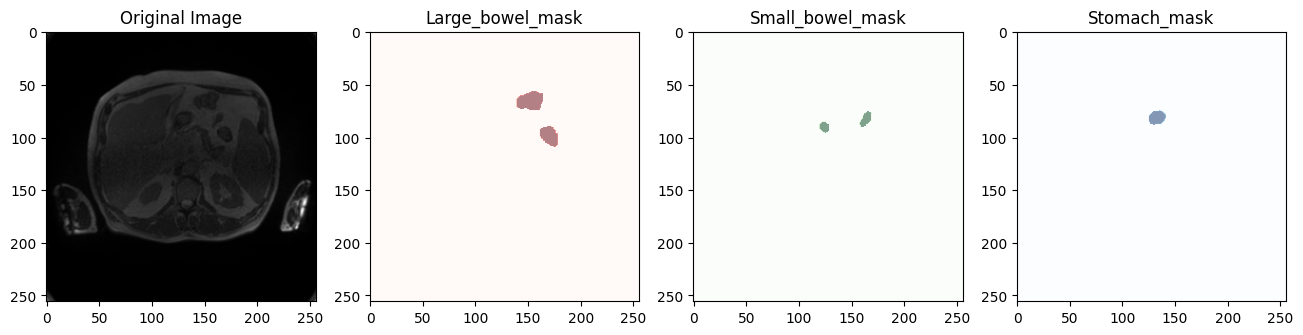

In [31]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots (1,4, figsize= (16,10))

axs[0].imshow(image_sanity[0, :, :], cmap='gray')


axs[1].imshow(mask_sanity [0, :, :], cmap='Reds', alpha = 0.5)   # Large Bowel
axs[2].imshow(mask_sanity[1, :, :], cmap='Greens', alpha = 0.5) # Small Bowel
axs[3].imshow(mask_sanity[2, :, :], cmap='Blues', alpha = 0.5)  # Stomach

axs[0].set_title("Original Image")
axs[1].set_title("Large_bowel_mask")
axs[2].set_title("Small_bowel_mask")
axs[3].set_title("Stomach_mask")
plt.show()

DEBUG: Index 1078 | ID: case133_day25_slice_0071 | File: slice_0071_360_310_1.50_1.50.png


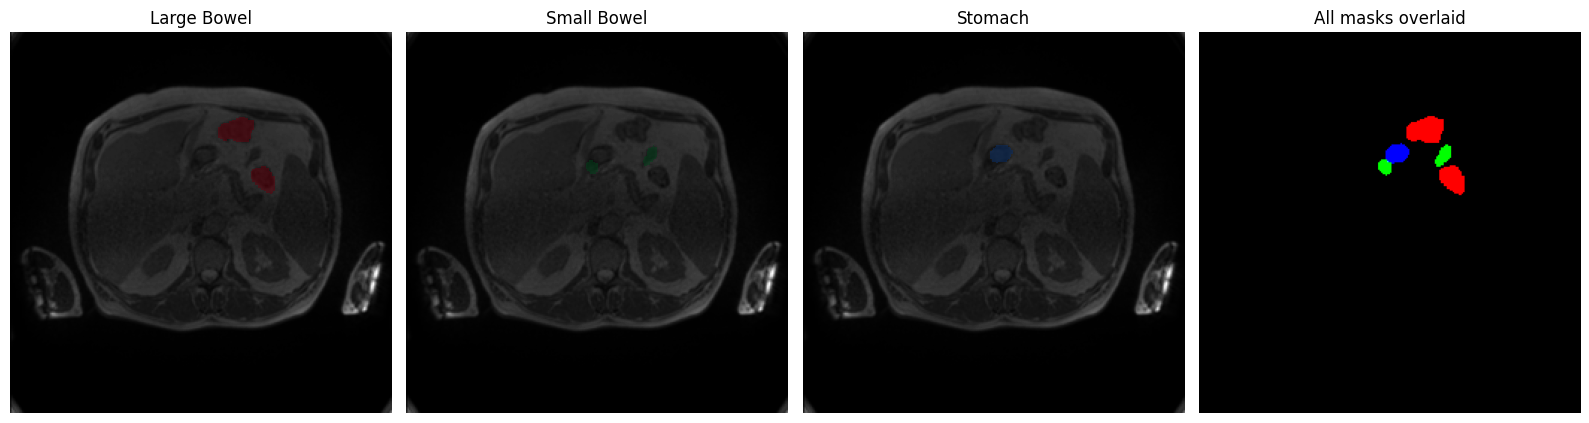

In [ ]:
# BY Dr Claude: I do not fully understand

import matplotlib.pyplot as plt
import numpy as np

image_sanity, mask_sanity = dataset_for_sanity_check.__getitem__(idx=1078)

img = image_sanity[0].numpy()      # (H, W)
masks = mask_sanity.numpy()        # (3, H, W)
class_names = ["Large Bowel", "Small Bowel", "Stomach"]
cmaps = ["Reds", "Greens", "Blues"]

fig, axs = plt.subplots(1, 4, figsize=(16, 5))

# Panels 0-2: image with one mask overlaid each
for i in range(3):
    axs[i].imshow(img, cmap="gray")
    # mask the zeros so only the organ region is colored
    overlay = np.ma.masked_where(masks[i] == 0, masks[i])
    axs[i].imshow(overlay, cmap=cmaps[i], alpha=0.5, vmin=0, vmax=1)
    axs[i].set_title(class_names[i])
    axs[i].axis("off")

# Panel 3: all three masks on the image at once
axs[3].imshow(img, cmap="gray")
rgb = np.zeros((*img.shape, 3))
rgb[..., 0] = masks[0]   # R = large bowel
rgb[..., 1] = masks[1]   # G = small bowel
rgb[..., 2] = masks[2]   # B = stomach
combined = np.ma.masked_where(masks.sum(0) == 0, np.ones_like(img))
axs[3].imshow(rgb, alpha=0.5 * (masks.sum(0) > 0))
axs[3].set_title("All masks overlaid")
axs[3].axis("off")

plt.tight_layout()
plt.show()


idx=1078
sample_id (from dataset): case133_day25_slice_0071
resolved path           : slice_0071_360_310_1.50_1.50.png
id round-trip           : OK
image size (W,H)        : (360, 310)  (matches filename)
  large_bowel :   1033 px
  small_bowel :    312 px
  stomach     :    280 px


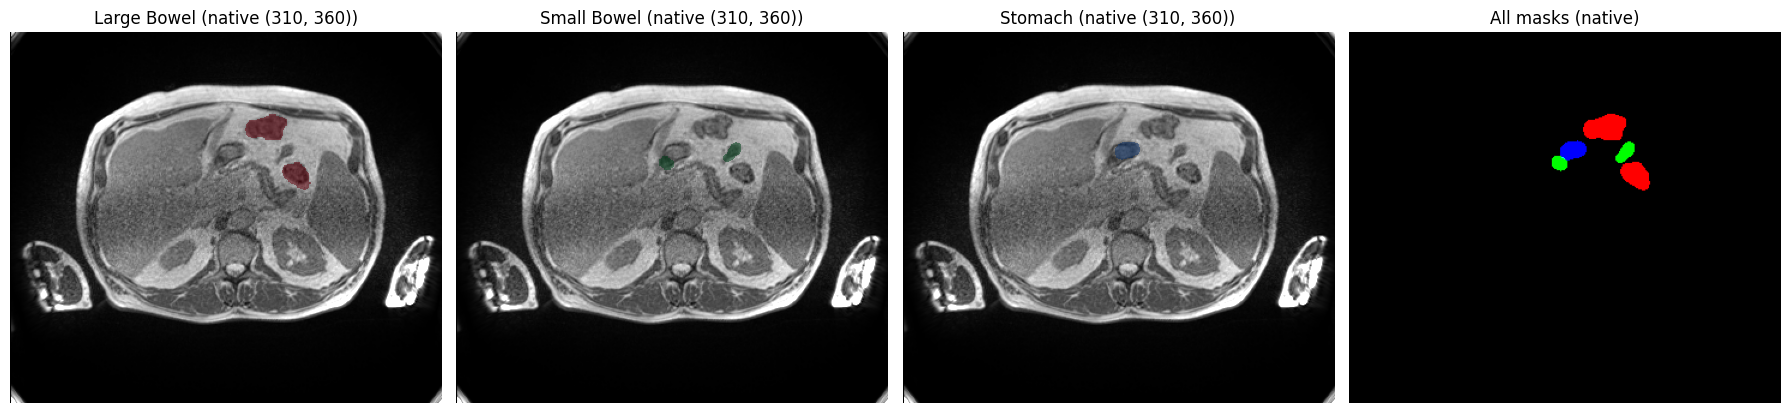

All assertions passed.


In [33]:
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

def verify_sample(dataset, idx):
    sample_id = dataset.ids[idx]
    img_path = Path(dataset.path_map[sample_id])
    print(f"idx={idx}")
    print(f"sample_id (from dataset): {sample_id}")
    print(f"resolved path           : {img_path.name}")

    # --- 1. Independently reconstruct the id from the path and compare ---
    day_folder = img_path.parent.parent.name           # caseXXX_dayYY
    slice_part = "_".join(img_path.stem.split("_")[:2]) # slice_NNNN
    reconstructed = f"{day_folder}_{slice_part}"
    assert reconstructed == sample_id, \
        f"ID MISMATCH: csv={sample_id} vs path={reconstructed}"
    print(f"id round-trip           : OK")

    # --- 2. Parse W/H from filename, confirm against the actual image ---
    # filename: slice_NNNN_<W>_<H>_<sx>_<sy>.png
    parts = img_path.stem.split("_")
    fname_w, fname_h = int(parts[2]), int(parts[3])
    raw_img = Image.open(img_path)                      # native, no convert('L')
    w, h = raw_img.size
    assert (w, h) == (fname_w, fname_h), \
        f"SIZE MISMATCH: PIL={(w,h)} vs filename={(fname_w,fname_h)}"
    print(f"image size (W,H)        : {(w, h)}  (matches filename)")

    native_shape = (h, w)
    img_native = np.array(raw_img, dtype=np.float32)
    assert img_native.shape == native_shape, \
        f"ARRAY SHAPE MISMATCH: {img_native.shape} vs {native_shape}"

    # --- 3. Decode masks directly from the CSV rows for this id, at native res ---
    rows = dataset.grouped.get_group(sample_id)
    masks = []
    for cls in dataset.classes:
        rle = rows.loc[rows["class"] == cls, "segmentation"].values[0]
        m = rle_to_binary(rle, native_shape)
        assert m.shape == native_shape, f"MASK SHAPE {m.shape} != {native_shape}"
        masks.append(m)
        nz = int(m.sum())
        print(f"  {cls:12s}: {nz:6d} px"
              + ("" if nz else "   (EMPTY)"))
    masks = np.stack(masks)

    # --- 4. Overlay at NATIVE resolution (non-square -> exposes transpose) ---
    class_names = ["Large Bowel", "Small Bowel", "Stomach"]
    cmaps = ["Reds", "Greens", "Blues"]
    fig, axs = plt.subplots(1, 4, figsize=(18, 6))

    vmax = np.percentile(img_native, 99)  # contrast stretch for visibility
    for i in range(3):
        axs[i].imshow(img_native, cmap="gray", vmax=vmax)
        overlay = np.ma.masked_where(masks[i] == 0, masks[i])
        axs[i].imshow(overlay, cmap=cmaps[i], alpha=0.5, vmin=0, vmax=1)
        axs[i].set_title(f"{class_names[i]} (native {native_shape})")
        axs[i].axis("off")

    axs[3].imshow(img_native, cmap="gray", vmax=vmax)
    rgb = np.stack([masks[0], masks[1], masks[2]], axis=-1).astype(float)
    axs[3].imshow(rgb, alpha=0.5 * (masks.sum(0) > 0))
    axs[3].set_title("All masks (native)")
    axs[3].axis("off")
    plt.tight_layout()
    plt.show()

    print("All assertions passed.")

verify_sample(dataset_for_sanity_check, idx=1078)


In [36]:
from collections import Counter

counts = Counter()
for p in dataset_for_sanity_check.path_map.values():
    p = Path(p)
    day_folder = p.parent.parent.name
    slice_part = "_".join(p.stem.split("_")[:2])
    counts[f"{day_folder}_{slice_part}"] += 1

dupes = {k: v for k, v in counts.items() if v > 1}
print(f"path_map size: {len(dataset_for_sanity_check.path_map)}")
print(f"colliding ids: {len(dupes)}")


path_map size: 38496
colliding ids: 0


<center>



### **The End of Sanity Check**




---

STEP 2: Splitting

just keep in mind:

The Problem: Data Leakage
In your dataset, one patient (one case_id) has many slices.

The “Leak”: If you use random_split blindly, “Case 123 - Slice 5” might end up in the training set, while “Case 123 - Slice 6” ends up in the validation set.
The Result: Since the slices are almost identical, your model will “memorize” the patient’s anatomy rather than learning to segment organs. Your validation score will look amazing, but when you test on a new patient, your model will fail completely.
The Correct Way (The “Group-Aware” Split)
To keep using PyTorch’s splitting utilities (like Subset), you need to perform the split based on unique patient IDs first, then map those back to indices.

Here is the standard, professional approach for medical imaging:

In [4]:
from sklearn.model_selection import train_test_split

full_df = pd.read_csv("/Users/ali/Desktop/madison/train.csv")
full_df['case_id'] = full_df['id'].str.split('_').str[0]

all_case_ids = full_df['case_id'].unique()
train_ids, val_ids = train_test_split(all_case_ids, test_size=0.2, random_state=42)

train_df = full_df[full_df['case_id'].isin(train_ids)].copy()
val_df   = full_df[full_df['case_id'].isin(val_ids)].copy()






####### Mini-Dataset (comment out this block for full training) ########
#def sample_by_slice(df, n_slices, seed=42):
#    ids = df['id'].drop_duplicates().sample(frac=1, random_state=seed).head(n_slices)
#    return df[df['id'].isin(ids)].copy()
#
#train_df = sample_by_slice(train_df, n_slices=100)
#val_df   = sample_by_slice(val_df, n_slices=20)
######################################################################





train_df.to_csv('train_split.csv', index=False)
val_df.to_csv('val_split.csv', index=False)


In [5]:
full_df.describe, train_df.describe, val_df.describe

(<bound method NDFrame.describe of                               id        class segmentation  case_id
 0       case123_day20_slice_0001  large_bowel          NaN  case123
 1       case123_day20_slice_0001  small_bowel          NaN  case123
 2       case123_day20_slice_0001      stomach          NaN  case123
 3       case123_day20_slice_0002  large_bowel          NaN  case123
 4       case123_day20_slice_0002  small_bowel          NaN  case123
 ...                          ...          ...          ...      ...
 115483    case30_day0_slice_0143  small_bowel          NaN   case30
 115484    case30_day0_slice_0143      stomach          NaN   case30
 115485    case30_day0_slice_0144  large_bowel          NaN   case30
 115486    case30_day0_slice_0144  small_bowel          NaN   case30
 115487    case30_day0_slice_0144      stomach          NaN   case30
 
 [115488 rows x 4 columns]>,
 <bound method NDFrame.describe of                              id        class segmentation case_id
 1296 

In [6]:
# Instanciate dataset class
train_dataset = MadisonDataset(csv_file='/Users/ali/Desktop/train_split.csv' , img_dir= '/Users/ali/Desktop/madison/train', transform=train_transform)
val_dataset = MadisonDataset(csv_file= '/Users/ali/Desktop/val_split.csv', img_dir= '/Users/ali/Desktop/madison/train', transform=None)

In [7]:
img, mask = train_dataset[0]

print(img.shape)
print(mask.shape)

torch.Size([3, 320, 352])
torch.Size([3, 320, 352])


STEP3: DataLoader definition

In [8]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

---

<center>



### **Sanity Check**




In [22]:
sanity_check_data_loader = DataLoader (train_dataset, batch_size=1, shuffle=True)
sanity_check_iter = iter(sanity_check_data_loader)

Batch: torch.Size([1, 1, 256, 256]), torch.Size([1, 3, 256, 256])


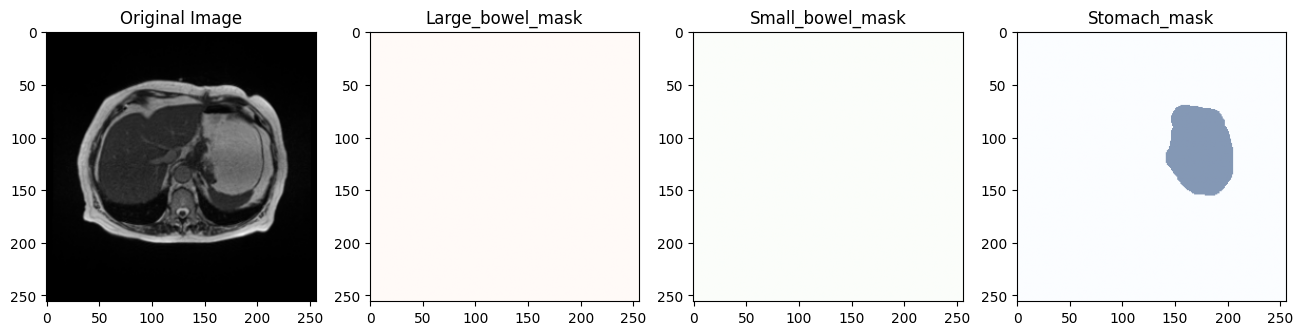

In [23]:
image_for_sanity, mask_for_sanity = next(sanity_check_iter)
print(f"Batch: {image_for_sanity.shape}, {mask_for_sanity.shape}")

#expected output?
#image should have this dimension (1= batch size, 1= channels, 256 =pixels in height, 256 =pixels in width)
#mask should have this dimension (1= batch size, 3= channels, 256 =pixels in height, 256 =pixels in width).
#number of channels for mask is three, because we have 3 mask layers (large bowel, small bowel, and stomach)


#And also lets visualize:
import matplotlib.pyplot as plt
fig, axs = plt.subplots (1,4, figsize= (16,10))

axs[0].imshow(image_for_sanity[0, 0, :, :], cmap='gray')


axs[1].imshow(mask_for_sanity[0, 0, :, :], cmap='Reds', alpha = 0.5)   # Large Bowel
axs[2].imshow(mask_for_sanity[0, 1, :, :], cmap='Greens', alpha = 0.5) # Small Bowel
axs[3].imshow(mask_for_sanity[0, 2, :, :], cmap='Blues', alpha = 0.5)  # Stomach

axs[0].set_title("Original Image")
axs[1].set_title("Large_bowel_mask")
axs[2].set_title("Small_bowel_mask")
axs[3].set_title("Stomach_mask")
plt.show()

<center>



### **The End of Sanity Check**

---

STEP 4: Model

In [9]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name= 'timm-efficientnet-b4', 
    encoder_weights='imagenet',
    in_channels=3,       
    classes=3,           # This is correct (Stomach, Small Bowel, Large Bowel)
    activation=None      # MUST be None to output raw logits for BCEWithLogitsLoss
)


device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
model = model.to(device)

/Users/ali/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [ ]:
#model = torch.load("/Users/ali/Desktop/V_6/best_model_dice_oriented.pth", weights_only=False)


---

<center>



### **Sanity Check**




In [39]:
mask_generated_by_model = model (image_for_sanity.to(device))
print(f"Batch: {image_for_sanity.shape}, {mask_for_sanity.shape}")

Batch: torch.Size([1, 1, 256, 256]), torch.Size([1, 3, 256, 256])


Text(0.5, 1.0, 'Model_generated')

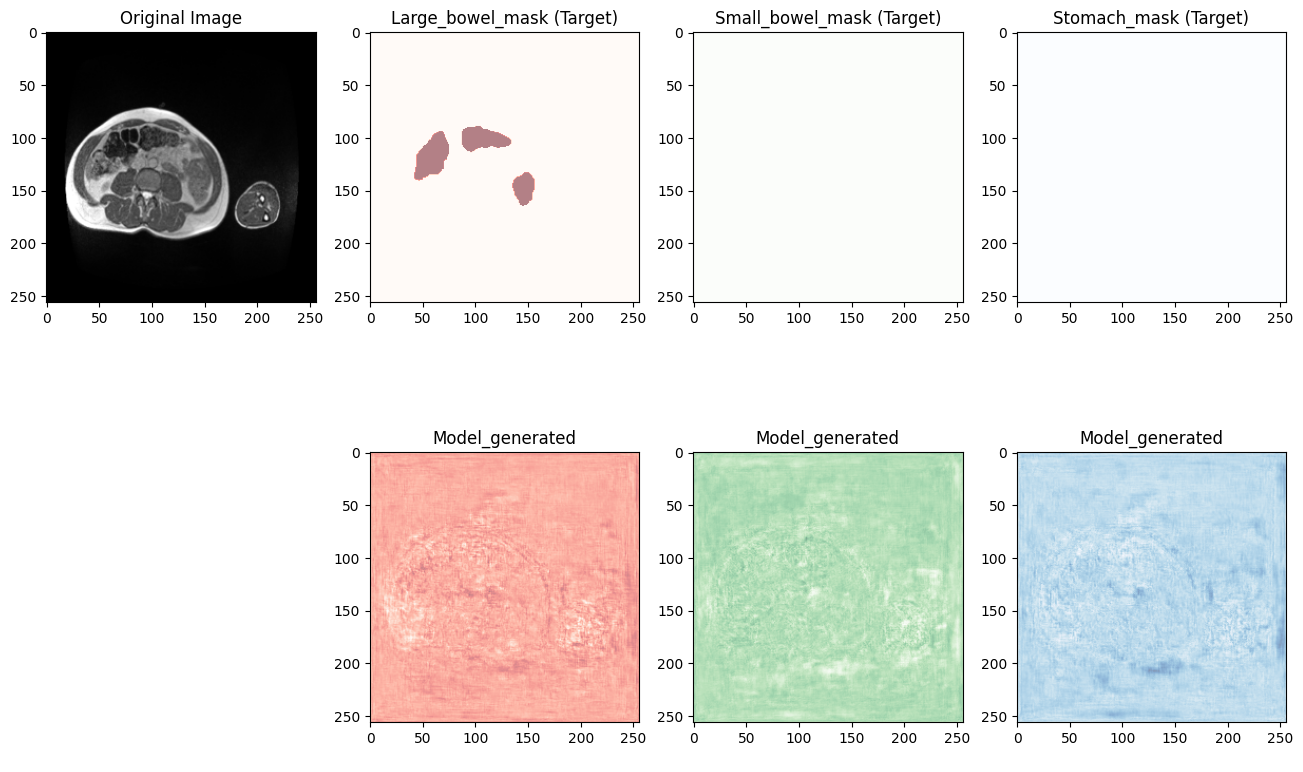

In [98]:
import matplotlib.pyplot as plt
fig, axs = plt.subplots (2,4, figsize= (16,10))

axs[0,0].imshow(image_for_sanity[0, 0, :, :], cmap='gray')


axs[0,1].imshow(mask_for_sanity[0, 0, :, :], cmap='Reds', alpha = 0.5)   # Large Bowel
axs[0,2].imshow(mask_for_sanity[0, 1, :, :], cmap='Greens', alpha = 0.5) # Small Bowel
axs[0,3].imshow(mask_for_sanity[0, 2, :, :], cmap='Blues', alpha = 0.5)  # Stomach

#model generated mask:

mask_generated_by_model_to_cpu = model (image_for_sanity.to(device)).detach().cpu().numpy()

axs[1,0].axis('off') 
axs[1,1].imshow(mask_generated_by_model_to_cpu[0, 0, :, :], cmap='Reds', alpha = 0.5)   # Large Bowel
axs[1,2].imshow(mask_generated_by_model_to_cpu[0, 1, :, :], cmap='Greens', alpha = 0.5) # Small Bowel
axs[1,3].imshow(mask_generated_by_model_to_cpu[0, 2, :, :], cmap='Blues', alpha = 0.5)  # Stomach


axs[0,0].set_title("Original Image")
axs[0,1].set_title("Large_bowel_mask (Target)")
axs[0,2].set_title("Small_bowel_mask (Target)")
axs[0,3].set_title("Stomach_mask (Target)")

axs[1,1].set_title("Model_generated")
axs[1,2].set_title("Model_generated")
axs[1,3].set_title("Model_generated")



<center>



### **The End of Sanity Check**

---

Choose the LossFunction and Optimizer

In [10]:
dice_loss = smp.losses.DiceLoss(mode='multilabel')
bce_loss = smp.losses.SoftBCEWithLogitsLoss()

def dice_bce_loss_function (predicted_logits, targets):
    return bce_loss(predicted_logits, targets) + dice_loss(predicted_logits, targets)

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

STEP 5: Trainig and Validation

In [ ]:
from tqdm import tqdm
import matplotlib.pyplot as plt

def train (train_loader, model, dice_bce_loss_function, optimizer, train_dataset, device):
    model.train ()
    loss_sum = 0
    for x_batch, y_batch in tqdm (train_loader):
        x_batch = x_batch.to(device).float()
        y_batch = y_batch.to(device).float()
        y_predicted = model (x_batch)
        optimizer.zero_grad()
        loss = dice_bce_loss_function (y_predicted, y_batch)
        loss.backward()
        optimizer.step()
        loss_sum += (loss.item() * len (x_batch))
    mean_loss_train = loss_sum / len (train_dataset)
    return mean_loss_train   


def calculate_dice(y_logits, y_true, smooth=1e-6):
    y_pred = (torch.sigmoid(y_logits) > 0.5).float() # we gave logit values to the loss_fun since it had built in sigmoid function. but here for dice calculation we must include a sigmoid function ourselves
    y_pred = y_pred.view(-1)
    y_true = y_true.view(-1)
    intersection = (y_pred * y_true).sum()
    return (2. * intersection + smooth) / (y_pred.sum() + y_true.sum() + smooth)



def validation(val_loader, model, val_dataset, dice_bce_loss_function, device):
    model.eval()
    loss_sum2 = 0.0
    dice_sum = 0.0

    with torch.no_grad():
        for x_batch_val, y_batch_val in val_loader:
            x_batch_val = x_batch_val.to(device).float()
            y_batch_val = y_batch_val.to(device).float()

            y_predicted_val = model(x_batch_val)
            loss_val = dice_bce_loss_function(y_predicted_val, y_batch_val)

            loss_sum2 += loss_val.item() * len (x_batch_val)
            dice_sum += calculate_dice(y_predicted_val, y_batch_val).item() * len(x_batch_val)

    mean_loss_val = loss_sum2 / len (val_dataset)
    avg_dice = dice_sum / len(val_dataset)
    return mean_loss_val, avg_dice



def learning_curve_plotter (list1, list2):
    plt.plot (list1, label='train_set')
    plt.plot (list2, label='val_set')
    plt.xlabel ('epoch')
    plt.ylabel ('loss')
    plt.legend()
    plt.show()



def operator(train_loader, val_loader, model, loss_fn, optimizer,
             train_dataset, val_dataset, n_epoch, device):
    list1 = []
    list2 = []
    best_dice_val = -torch.inf  # track best on dice, higher is better
    best_loss_val = torch.inf

    for epoch in range(n_epoch):
        mean_loss_train = train(train_loader, model, loss_fn, optimizer,train_dataset, device)
        mean_loss_val, mean_dice_val = validation(val_loader, model,val_dataset, loss_fn, device)
        list1.append(mean_loss_train)
        list2.append(mean_loss_val)

        print(f'Epoch {epoch+1}/{n_epoch} --> '
              f'train_loss: {mean_loss_train:.4f}, '
              f'val_loss: {mean_loss_val:.4f}, '
              f'val_dice: {mean_dice_val:.4f}')

        if mean_dice_val > best_dice_val:
            torch.save (model, '/Users/ali/Desktop/Saved/best_model_dice_oriented.pth')
            best_dice_val = mean_dice_val
            print('model saved! Dice-Oriented')

        if mean_loss_val < best_loss_val:
            torch.save (model, '/Users/ali/Desktop/Saved/best_model_loss_oriented.pth')
            best_loss_val = mean_loss_val
            print ('model saved! Loss-Oriented')

    learning_curve_plotter(list1, list2)


100%|██████████| 3826/3826 [1:13:23<00:00,  1.15s/it]


Epoch 1/30 --> train_loss: 0.5043, val_loss: 0.1545, val_dice: 0.7454
model saved! Dice-Oriented
model saved! Loss-Oriented


100%|██████████| 3826/3826 [1:17:52<00:00,  1.22s/it]


Epoch 2/30 --> train_loss: 0.2677, val_loss: 0.1359, val_dice: 0.8034
model saved! Dice-Oriented
model saved! Loss-Oriented


100%|██████████| 3826/3826 [1:16:14<00:00,  1.20s/it]


...

Epoch 28/30 --> train_loss: 0.1493, val_loss: 0.1162, val_dice: 0.8422


100%|██████████| 3826/3826 [1:16:15<00:00,  1.20s/it]


Epoch 29/30 --> train_loss: 0.1439, val_loss: 0.1113, val_dice: 0.8457
model saved! Loss-Oriented


100%|██████████| 3826/3826 [1:15:20<00:00,  1.18s/it]


Epoch 30/30 --> train_loss: 0.1443, val_loss: 0.1213, val_dice: 0.8190


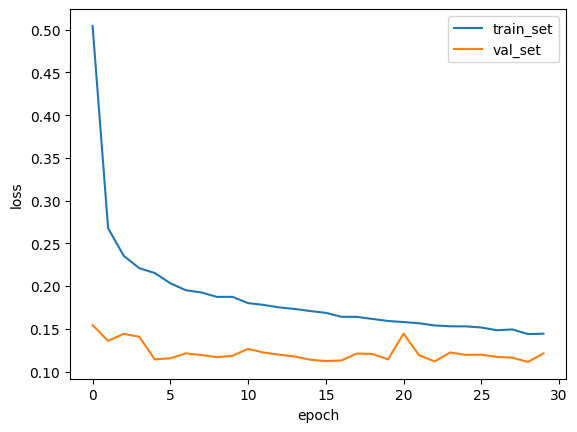

In [13]:
operator(train_loader=train_loader,
         val_loader=val_loader,
         model=model.to(device),
         loss_fn=dice_bce_loss_function,
         optimizer=optimizer,
         train_dataset=train_dataset,
         val_dataset=val_dataset,
         device=device,
         n_epoch=30)